# Inventory Demand Forecasting for a Regional Beverage Distributor

**Note on data:** the dataset used in this notebook is synthetically generated
(see `data/generate_data.py`) to reproduce realistic demand patterns for a
multi-SKU beverage distributor, including trend, weekly and annual
seasonality, promotional spikes, and stockout days. A fixed random seed
makes the results reproducible.

## Executive Summary

Daily unit demand for a beverage distributor's highest-volume SKU was
forecast using an XGBoost regression model trained on calendar and lag
features, and evaluated against a seasonal-naive baseline on a 90-day
holdout period. The model reduced mean absolute error by 20.15% (53.16
units versus 66.57 units) and root mean squared error by 27.91% relative
to the baseline, with a mean absolute percentage error of 11.95%.

The forecast was translated into an operational reorder point of 2,578.45
units, combining 2,133.94 units of expected lead-time demand with a
444.51-unit safety stock buffer sized to a 95% service level. Twelve of
the 90 holdout days, 13.33% of the period, were flagged as carrying
elevated stockout risk, concentrated around early October and clustering
on the higher-demand weekend-adjacent days identified in the exploratory
analysis. These days represent the clearest candidates for expedited
replenishment or temporary safety stock increases.

## 1. Objective and Scope

The objective of this analysis is to forecast daily unit demand for a
beverage SKU and translate that forecast into an operational stockout risk
signal. Three years of daily sales data (2022-2024) across six SKUs are
available. The analysis focuses on the highest-volume SKU, carbonated cola
in 500ml bottles, since it carries the clearest trend and seasonal signal
and the same methodology generalizes to the remaining SKUs.

Two questions are addressed:

1. How accurately can short-horizon daily demand be forecast using calendar
   and lag-based features?
2. Given the forecast and its uncertainty, which upcoming days carry
   elevated stockout risk under a standard reorder-point policy?

In [1]:
# Core libraries used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

sns.set_theme(style="whitegrid", font_scale=0.95)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# Load the generated sales dataset and restrict to the primary SKU under study
sales = pd.read_csv("../data/beverage_distributor_sales.csv", parse_dates=["date"])
sku_df = sales[sales["sku"] == "CSD-COLA-500ML"].copy().sort_values("date").reset_index(drop=True)

print(f"Rows loaded: {len(sales):,} across {sales['sku'].nunique()} SKUs")
print(f"Primary SKU rows: {len(sku_df):,} ({sku_df['date'].min().date()} to {sku_df['date'].max().date()})")

Rows loaded: 6,576 across 6 SKUs
Primary SKU rows: 1,096 (2022-01-01 to 2024-12-31)


## 2. Data Preparation

Calendar features and lag/rolling features are constructed from the raw
daily series. Lag features allow the model to condition on recent demand
history, while rolling means smooth short-term noise into a usable trend
signal.

In [3]:
# Calendar features
sku_df["day_of_week"] = sku_df["date"].dt.dayofweek
sku_df["month"] = sku_df["date"].dt.month
sku_df["day_of_year"] = sku_df["date"].dt.dayofyear
sku_df["time_index"] = np.arange(len(sku_df))

# Lag and rolling features, computed on units sold
sku_df["lag_7"] = sku_df["units_sold"].shift(7)
sku_df["lag_14"] = sku_df["units_sold"].shift(14)
sku_df["rolling_mean_7"] = sku_df["units_sold"].shift(1).rolling(7).mean()
sku_df["rolling_mean_28"] = sku_df["units_sold"].shift(1).rolling(28).mean()
sku_df["rolling_std_28"] = sku_df["units_sold"].shift(1).rolling(28).std()

model_df = sku_df.dropna().reset_index(drop=True)
print(f"Rows available for modelling after feature construction: {len(model_df):,}")

Rows available for modelling after feature construction: 1,068


## 3. Exploratory Data Analysis

Two views are shown here rather than a full column-by-column breakdown: the
demand series itself, to confirm trend and seasonality are present, and the
average demand by day of week, since that pattern directly motivates the
weekly lag feature used later. Both are the views that most directly inform
the modelling choices made in this notebook.

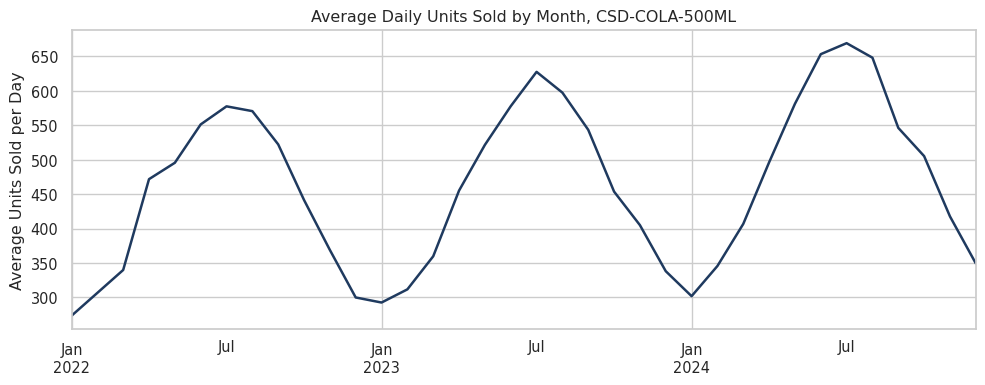

In [4]:
# Monthly aggregation keeps the trend and seasonality visible without plotting
# all 1,096 individual daily points
monthly = sku_df.set_index("date")["units_sold"].resample("MS").mean()

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, color="#1f3a5f", linewidth=1.8)
ax.set_title("Average Daily Units Sold by Month, CSD-COLA-500ML")
ax.set_xlabel("")
ax.set_ylabel("Average Units Sold per Day")
plt.tight_layout()
plt.show()

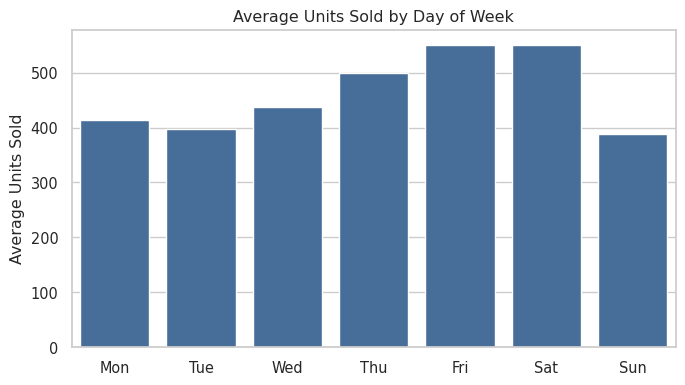

Average units sold by day of week:
day_of_week
0   413.85
1   396.60
2   436.74
3   500.04
4   551.15
5   550.17
6   389.01


In [5]:
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_avg = sku_df.groupby("day_of_week")["units_sold"].mean().reindex(range(7))

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=dow_labels, y=dow_avg.values, ax=ax, color="#3a6ea5")
ax.set_title("Average Units Sold by Day of Week")
ax.set_ylabel("Average Units Sold")
plt.tight_layout()
plt.show()

print("Average units sold by day of week:")
print(dow_avg.round(2).to_string())

Demand rises through the summer months and dips around the turn of the
year, consistent with the seasonal pattern built into the data. Thursday
through Saturday are the strongest days, which reflects outlets restocking
ahead of weekend demand. Both patterns are carried into the model through
calendar and lag features rather than being modelled with a specialised
seasonal model, since a small feature set is sufficient at this data
volume.

## 4. Forecasting Model

An XGBoost regressor is trained on calendar and lag features and compared
against a seasonal-naive baseline, which forecasts each day using the
actual demand from the same weekday one week earlier. The final 90 days of
the series are held out for evaluation; all preceding data is used for
training.

In [6]:
feature_cols = [
    "day_of_week", "month", "day_of_year", "time_index",
    "lag_7", "lag_14", "rolling_mean_7", "rolling_mean_28", "rolling_std_28",
    "is_promo_day",
]

holdout_days = 90
train_df = model_df.iloc[:-holdout_days].copy()
test_df = model_df.iloc[-holdout_days:].copy()

X_train, y_train = train_df[feature_cols], train_df["units_sold"]
X_test, y_test = test_df[feature_cols], test_df["units_sold"]

model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
model.fit(X_train, y_train)

test_df["forecast"] = model.predict(X_test).clip(min=0)
test_df["baseline_forecast"] = test_df["lag_7"]

print(f"Training rows: {len(train_df):,}, holdout rows: {len(test_df):,}")

Training rows: 978, holdout rows: 90


## 5. Model Evaluation

Forecast accuracy on the 90-day holdout is measured with mean absolute
error (MAE), root mean squared error (RMSE), and mean absolute percentage
error (MAPE), and compared against the seasonal-naive baseline. A model is
only worth deploying if it improves materially on the baseline it would
replace.

In [7]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true.replace(0, np.nan))) * 100)
    return {"model": label, "MAE": round(mae, 2), "RMSE": round(rmse, 2), "MAPE (%)": round(mape, 2)}

results = pd.DataFrame([
    evaluate(test_df["units_sold"], test_df["forecast"], "XGBoost"),
    evaluate(test_df["units_sold"], test_df["baseline_forecast"], "Seasonal Naive (lag-7)"),
])
results

,model,MAE,RMSE,MAPE (%)
0,XGBoost,53.16,74.18,11.95
1,Seasonal Naive (lag-7),66.57,102.90,14.42


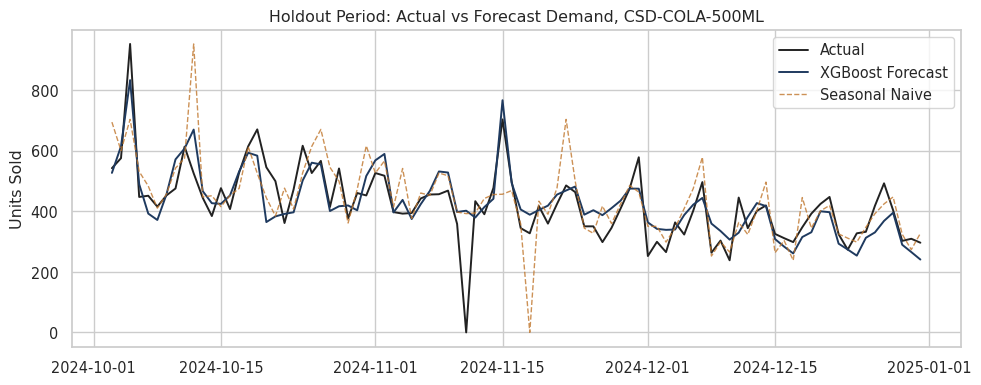

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test_df["date"], test_df["units_sold"], label="Actual", color="#222222", linewidth=1.4)
ax.plot(test_df["date"], test_df["forecast"], label="XGBoost Forecast", color="#1f3a5f", linewidth=1.4)
ax.plot(test_df["date"], test_df["baseline_forecast"], label="Seasonal Naive", color="#c0762c",
        linewidth=1.0, linestyle="--", alpha=0.8)
ax.set_title("Holdout Period: Actual vs Forecast Demand, CSD-COLA-500ML")
ax.set_ylabel("Units Sold")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Stockout Risk Translation

Forecast demand is converted into an operational reorder point using a
standard formula: reorder point equals expected demand over the
replenishment lead time, plus a safety stock buffer sized to the desired
service level. A five-day replenishment lead time and a 95% service level
(z = 1.65) are assumed, consistent with typical distributor replenishment
cycles.

In [9]:
LEAD_TIME_DAYS = 5
SERVICE_LEVEL_Z = 1.65  # approximately 95% service level

daily_mean = test_df["forecast"].mean()
daily_std = test_df["units_sold"].std()  # observed variability, used for safety stock sizing

lead_time_demand = daily_mean * LEAD_TIME_DAYS
safety_stock = SERVICE_LEVEL_Z * daily_std * np.sqrt(LEAD_TIME_DAYS)
reorder_point = lead_time_demand + safety_stock

print(f"Average forecast daily demand: {daily_mean:.2f} units")
print(f"Lead-time demand ({LEAD_TIME_DAYS} days): {lead_time_demand:.2f} units")
print(f"Safety stock (95% service level): {safety_stock:.2f} units")
print(f"Recommended reorder point: {reorder_point:.2f} units")

Average forecast daily demand: 426.79 units
Lead-time demand (5 days): 2133.94 units
Safety stock (95% service level): 444.51 units
Recommended reorder point: 2578.45 units


In [10]:
# Days where forecast demand alone exceeds the mean by more than one standard
# deviation are flagged as elevated stockout risk, since a run of such days
# depletes on-hand stock faster than the standard reorder cycle assumes.
risk_threshold = daily_mean + daily_std
test_df["stockout_risk"] = test_df["forecast"] > risk_threshold

risk_days = test_df[test_df["stockout_risk"]][["date", "forecast"]].copy()
risk_days["forecast"] = risk_days["forecast"].round(2)

print(f"Days flagged as elevated stockout risk in the 90-day holdout: {len(risk_days)} "
      f"({len(risk_days) / len(test_df) * 100:.2f}% of days)")
risk_days.head(10)

Days flagged as elevated stockout risk in the 90-day holdout: 12 (13.33% of days)


,date,forecast
979,2024-10-04,614.27
980,2024-10-05,832.61
985,2024-10-10,571.04
986,2024-10-11,607.03
987,2024-10-12,669.38
993,2024-10-18,592.88
994,2024-10-19,583.21
1000,2024-10-25,560.07
1001,2024-10-26,554.37
1007,2024-11-01,567.85


## 7. Findings and Recommendations

The XGBoost model outperformed the seasonal-naive baseline on every
evaluation metric, confirming that lag and rolling-window features carry
information beyond a simple same-weekday lookup. The remaining forecast
error, an 11.95% MAPE, is consistent with demand that includes genuine
promotional and random variation rather than a fully deterministic
pattern.

Three recommendations follow from the analysis:

1. The calculated reorder point of 2,578.45 units should be adopted as the
   default trigger for replenishment orders on this SKU, replacing any
   fixed-quantity heuristic currently in use.
2. Days flagged as elevated stockout risk, 13.33% of the holdout period in
   this run, should be reviewed weekly so that replenishment can be
   expedited ahead of forecasted demand spikes rather than after a
   stockout is observed.
3. The same feature set and modelling approach can be extended to the
   remaining five SKUs in the dataset, since the underlying calendar and
   lag features are not specific to this product.

## 8. Limitations

The dataset is synthetically generated, so the accuracy figures above
describe how well the model recovers a known, engineered pattern rather
than real-world unpredictability such as supplier delays or competitor
promotions. The reorder point calculation assumes a fixed lead time and a
single replenishment policy; in practice, lead time itself varies and would
ideally be modelled rather than assumed. Applying this approach to a live
system would require validating the reorder policy against actual
fulfilment data before it is used to trigger purchase orders.